In [5]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv('../Data/raw/trainincome_data.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [7]:
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  Income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [9]:
df.shape

(32561, 15)

In [10]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
Income            0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(24)

In [12]:
for col in df.columns:
    print("Column:", col)
    print(df[col].unique())
    print("------")

Column: age
[39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
------
Column: workclass
<StringArray>
[       ' State-gov', ' Self-emp-not-inc',          ' Private',
      ' Federal-gov',        ' Local-gov',                ' ?',
     ' Self-emp-inc',      ' Without-pay',     ' Never-worked']
Length: 9, dtype: str
------
Column: fnlwgt
[ 77516  83311 215646 ...  34066  84661 257302]
------
Column: education
<StringArray>
[   ' Bachelors',      ' HS-grad',         ' 11th',      ' Masters',
          ' 9th', ' Some-college',   ' Assoc-acdm',    ' Assoc-voc',
      ' 7th-8th',    ' Doctorate',  ' Prof-school',      ' 5th-6th',
         ' 10th',      ' 1st-4th',    ' Preschool',         ' 12th']
Length: 16, dtype: str
------
Column: education-num
[13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
------
Column: marital-s

In [13]:
object_cols = df.select_dtypes(include=['object', 'string']).columns
for col in object_cols:
    df[col] = df[col].str.strip()


In [14]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [15]:
df.describe(include='string')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,Income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


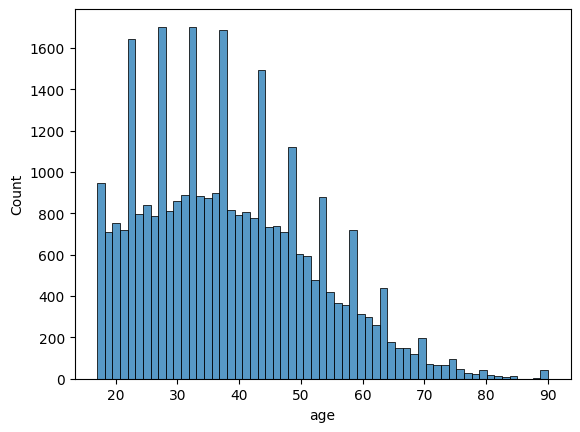

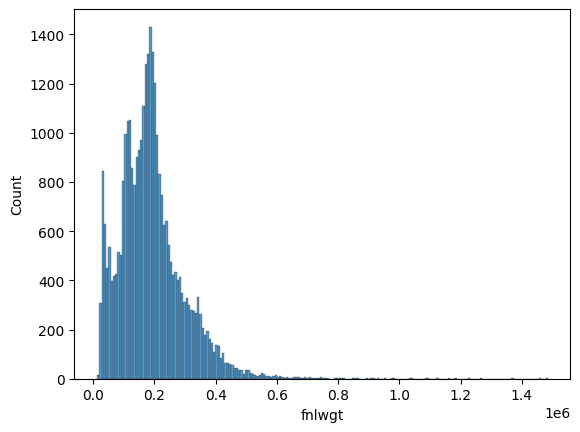

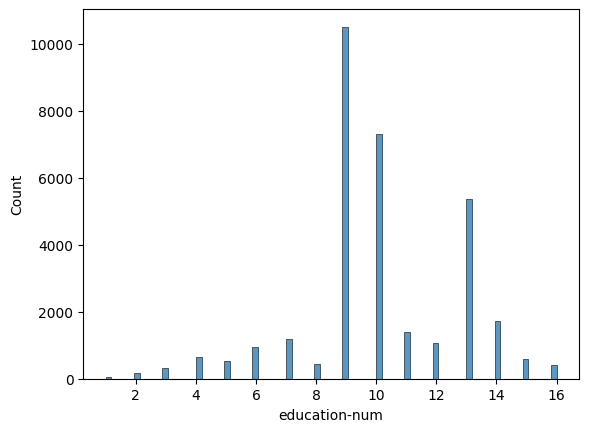

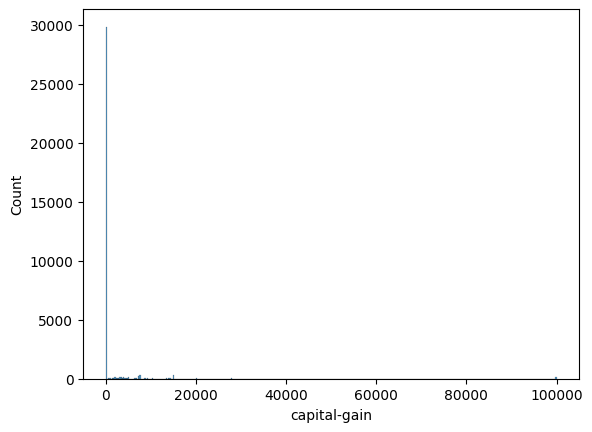

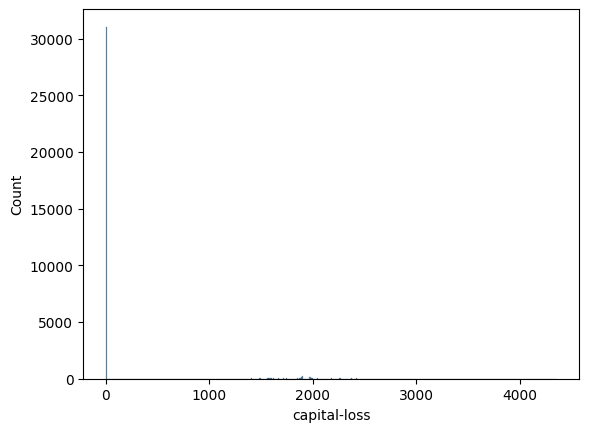

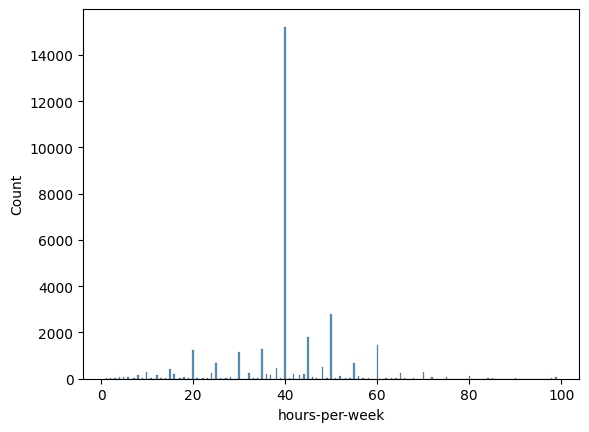

In [16]:
for i in df.select_dtypes(include="number").columns:
    sns.histplot(data=df,x=i)
    plt.show()

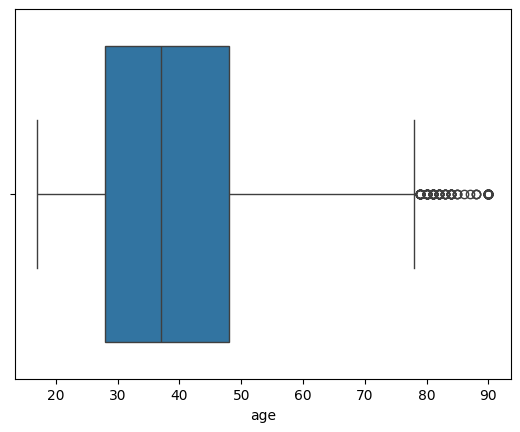

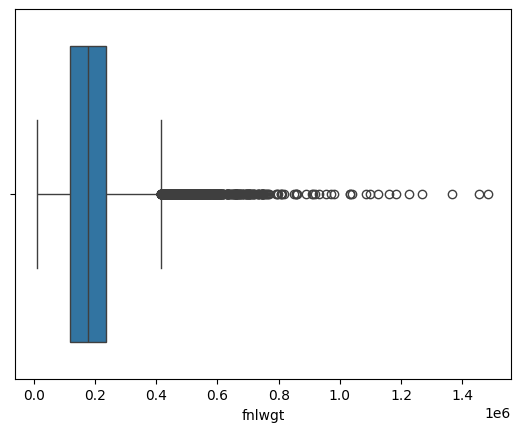

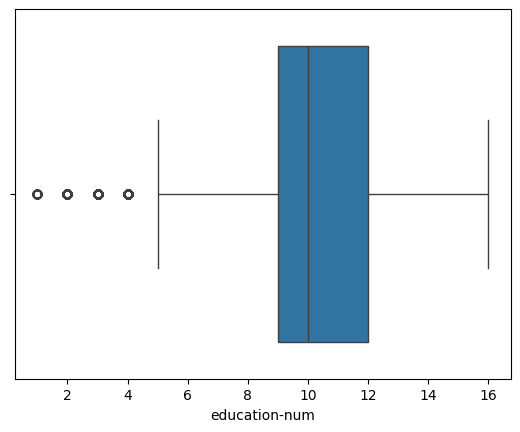

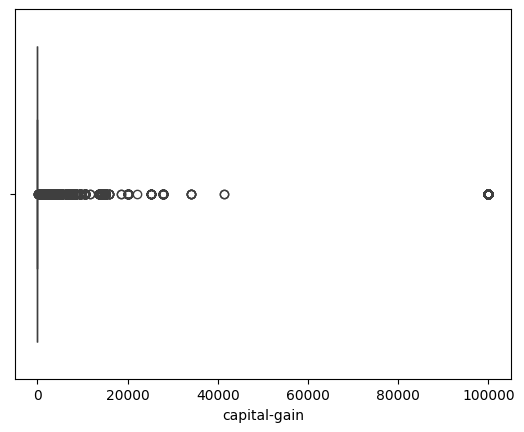

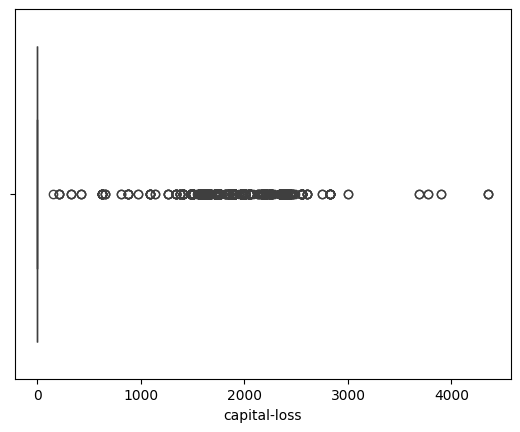

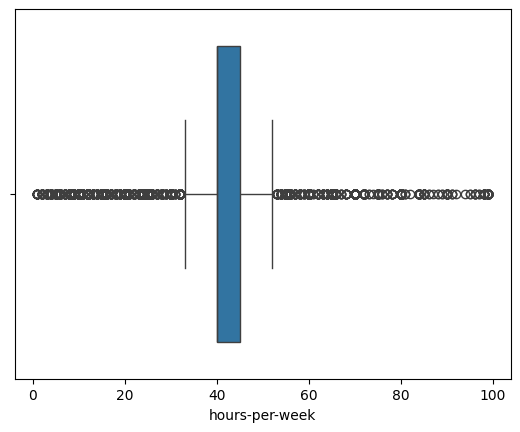

In [17]:
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show() 

<Axes: xlabel='age', ylabel='hours-per-week'>

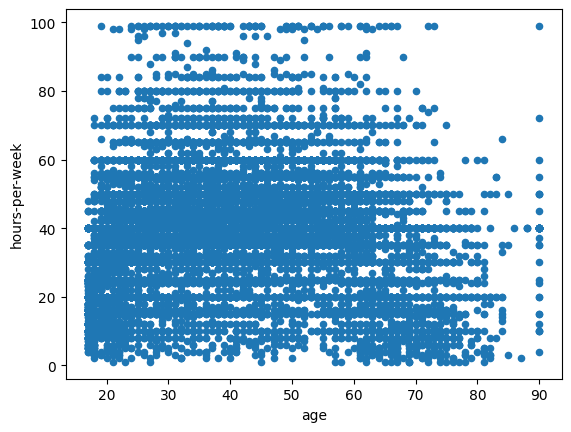

In [18]:
df.plot.scatter(x='age', y='hours-per-week')

<Axes: xlabel='age', ylabel='education-num'>

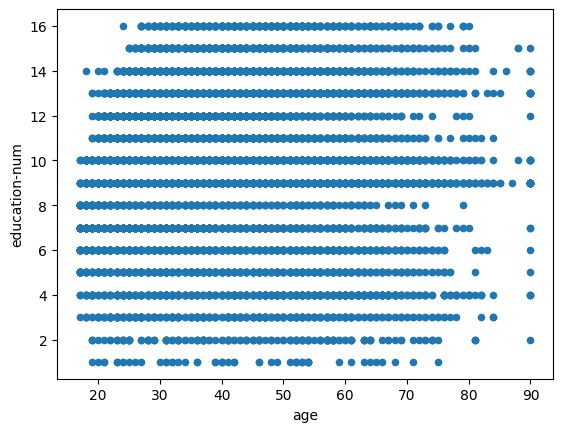

In [19]:
df.plot.scatter(x='age', y='education-num')

<Axes: xlabel='hours-per-week', ylabel='education-num'>

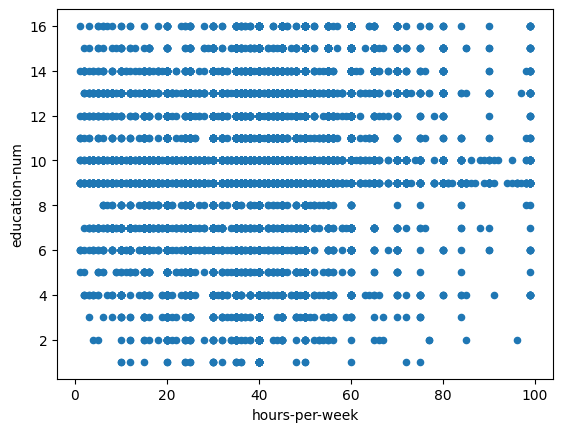

In [20]:
df.plot.scatter(x='hours-per-week', y='education-num')

In [21]:
# there is no correlation between the features
df.select_dtypes(include="number").corr()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education-num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital-gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital-loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours-per-week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


<Axes: >

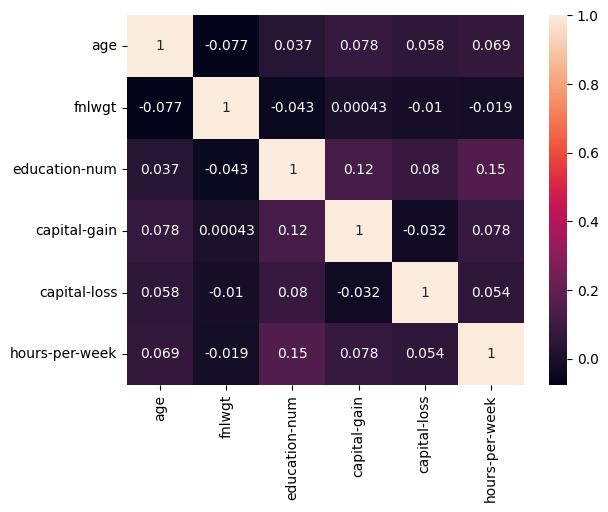

In [22]:
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True)

<Axes: xlabel='education', ylabel='count'>

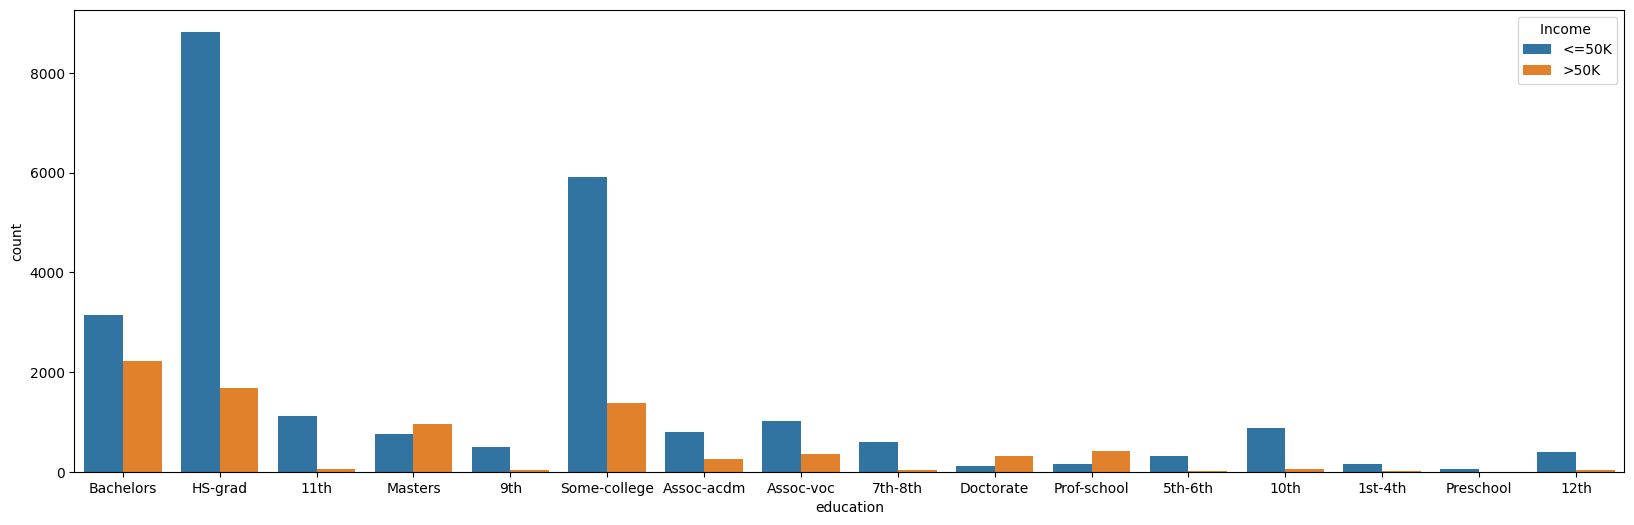

In [23]:
plt.figure(figsize=(20, 6))
sns.countplot(x='education', hue='Income ', data=df)

In [24]:
# handling garbage values
df.replace('?', np.nan, inplace=True)
for col in ['workclass', 'occupation', 'native-country']:
    df[col] = df[col].fillna(df[col].mode()[0])

In [25]:
df.isnull().values.any()

np.False_

In [26]:
(df == "unknown").sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
Income            0
dtype: int64

In [28]:
num_cols=df.select_dtypes(include='int64').columns
print(num_cols)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='str')


In [31]:
def outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    return print(column,":",outliers.shape[0])
      

for col in num_cols :
    outliers_iqr(df,col)

age : 143
fnlwgt : 992
education-num : 1198
capital-gain : 2712
capital-loss : 1519
hours-per-week : 9008


In [33]:
df['capital-gain']=np.log1p(df['capital-gain'])
df['capital-loss']=np.log1p(df['capital-loss'])

<Axes: xlabel='capital-gain'>

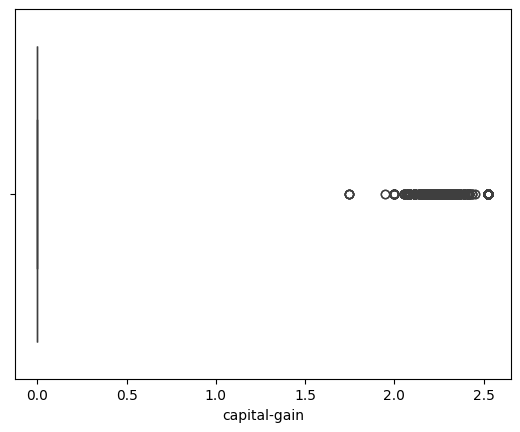

In [38]:
sns.boxplot(data=df,x=df['capital-gain'])

<Axes: ylabel='capital-loss'>

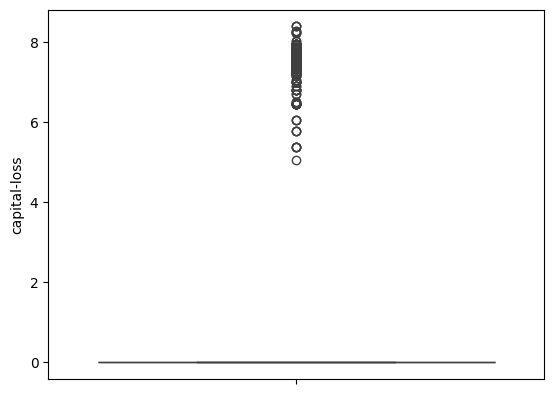

In [ ]:
sns.boxplot(data=df,x=df['capital-loss'])

In [40]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['age'] = df['age'].clip(lower, upper)

In [42]:
Q1 = df['hours-per-week'].quantile(0.25)
Q3 = df['hours-per-week'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['hours-per-week'] = df['hours-per-week'].clip(lower, upper)

<Axes: xlabel='age'>

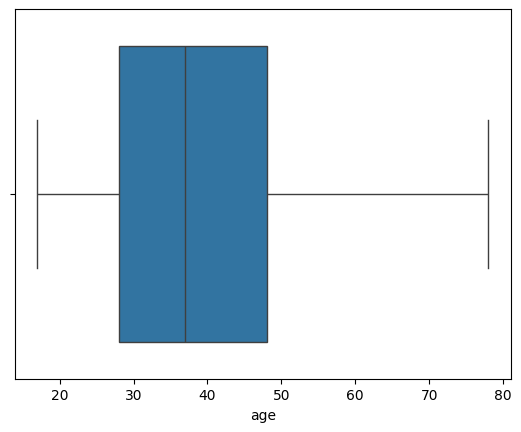

In [44]:
sns.boxplot(data=df,x=df['age'])

<Axes: xlabel='hours-per-week'>

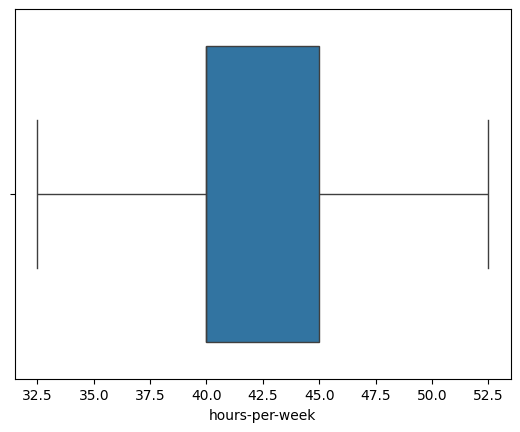

In [45]:
sns.boxplot(data=df,x=df['hours-per-week'])

In [46]:
df.drop('fnlwgt', axis=1, inplace=True)

In [47]:
df.columns.tolist()

['age',
 'workclass',
 'education',
 'education-num',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'capital-gain',
 'capital-loss',
 'hours-per-week',
 'native-country',
 'Income ']

In [49]:
df.duplicated().sum()

np.int64(4521)

In [50]:
df[df.duplicated()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
352,33,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
371,17,Private,11th,7,Never-married,Other-service,Own-child,White,Male,0.0,0.0,32.5,United-States,<=50K
391,27,Private,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,0.0,0.0,50.0,United-States,<=50K
517,20,Private,Some-college,10,Never-married,Prof-specialty,Own-child,White,Male,0.0,0.0,32.5,United-States,<=50K
563,24,Private,HS-grad,9,Never-married,Handlers-cleaners,Unmarried,Black,Female,0.0,0.0,40.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32512,20,Private,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
32527,22,Private,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
32542,72,Private,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,32.5,United-States,<=50K
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States,>50K


In [51]:
df[df.duplicated(keep=False)]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,Income
12,23,Private,Bachelors,13,Never-married,Adm-clerical,Own-child,White,Female,0.0,0.0,32.5,United-States,<=50K
17,32,Private,HS-grad,9,Never-married,Machine-op-inspct,Unmarried,White,Male,0.0,0.0,40.0,United-States,<=50K
20,40,Private,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,52.5,United-States,>50K
26,19,Private,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
29,49,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0.0,0.0,40.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32512,20,Private,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
32527,22,Private,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K
32542,72,Private,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0.0,0.0,32.5,United-States,<=50K
32557,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States,>50K


In [53]:
df=df.drop_duplicates()

In [56]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
32554    False
32555    False
32556    False
32558    False
32560    False
Length: 28040, dtype: bool

In [58]:
df['native-country'].value_counts()

native-country
United-States                 25248
Mexico                          632
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            79
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        62
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           50
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
France                           29
Greece       

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = df.select_dtypes(include='number') 
X_train_scaled = scaler.fit_transform(x_train)

In [69]:
print(X_train_scaled)

[[-0.0484755   1.0789396   2.89155588 -0.23817404 -0.24376676]
 [ 0.774181    1.0789396  -0.32545542 -0.23817404 -1.44547213]
 [-0.12326245 -0.42148649 -0.32545542 -0.23817404 -0.24376676]
 ...
 [-0.94591894  0.70383308 -0.32545542 -0.23817404 -0.56422153]
 [ 1.37247663 -0.42148649 -0.32545542 -0.23817404 -0.24376676]
 [ 0.92375491 -0.42148649  3.19059217 -0.23817404 -0.24376676]]


In [70]:
scaled_df = pd.DataFrame(X_train_scaled, columns=x_train.columns)
print(scaled_df.head())

        age  education-num  capital-gain  capital-loss  hours-per-week
0 -0.048475       1.078940      2.891556     -0.238174       -0.243767
1  0.774181       1.078940     -0.325455     -0.238174       -1.445472
2 -0.123262      -0.421486     -0.325455     -0.238174       -0.243767
3  0.998542      -1.171700     -0.325455     -0.238174       -0.243767
4 -0.871132       1.078940     -0.325455     -0.238174       -0.243767


In [71]:
scaled_df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,2.804000e+04,2.804000e+04,2.804000e+04,28040.000000,2.804000e+04
mean,-2.493488e-16,-4.814662e-17,4.257175e-17,0.000000,3.740232e-16
std,1.000018e+00,1.000018e+00,1.000018e+00,1.000018,1.000018e+00
min,-1.693788e+00,-3.422339e+00,-3.254554e-01,-0.238174,-1.445472e+00
25%,-7.963450e-01,-4.214865e-01,-3.254554e-01,-0.238174,-2.437668e-01
50%,-1.232624e-01,-4.637997e-02,-3.254554e-01,-0.238174,-2.437668e-01
75%,6.993940e-01,1.078940e+00,-3.254554e-01,-0.238174,5.573702e-01
max,2.868216e+00,2.204259e+00,3.435058e+00,4.707136,1.759076e+00


In [72]:
print("Before scaling:")
print(x_train.describe())

print("\nAfter scaling:")
print(scaled_df.describe())

Before scaling:
                age  education-num  capital-gain  capital-loss  hours-per-week
count  28040.000000   28040.000000  28040.000000  28040.000000    28040.000000
mean      39.648181      10.123645      0.218680      0.403572       41.521380
std       13.371555       2.665957      0.671931      1.694472        6.241242
min       17.000000       1.000000      0.000000      0.000000       32.500000
25%       29.000000       9.000000      0.000000      0.000000       40.000000
50%       38.000000      10.000000      0.000000      0.000000       40.000000
75%       49.000000      13.000000      0.000000      0.000000       45.000000
max       78.000000      16.000000      2.526762      8.379539       52.500000

After scaling:
                age  education-num  capital-gain  capital-loss  hours-per-week
count  2.804000e+04   2.804000e+04  2.804000e+04  28040.000000    2.804000e+04
mean  -2.493488e-16  -4.814662e-17  4.257175e-17      0.000000    3.740232e-16
std    1.000018e+00 